In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/kenya.csv")
df["Country"] = "Kenya"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.428493,27.834314,14.675061,13.159253,1.468072,65.848264,3.066646,4.377237,83.721582,11.054447,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.690000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.470000,26.270000,13.700000,11.457500,0.100000,58.677500,2.430000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.870000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.760000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440060,2.362025,1.416987,2.611634,3.186852,9.936065,0.849009,0.990825,0.125928,1.610232,NaN,3.477046


### Data Overview

The dataset contains 4,108 records spanning from 2015 to 2026, representing daily climate observations for Kenya.  
After replacing missing values (-999) with NaN and removing duplicates, the dataset appears clean and consistent, with no loss of rows.

A new `DATE` column was created from `YEAR` and `DOY`, and a `Month` feature was extracted to support seasonal analysis.

---

### Temperature Patterns

The average temperature (`T2M`) is around 20.4°C, with maximum and minimum averages of 27.8°C and 14.7°C respectively.  
The temperature range averages about 13.2°C, indicating noticeable variation between daytime and nighttime temperatures.

Overall, temperature variability is low (std ≈ 1.44), suggesting a relatively stable climate.

---

### Precipitation Behavior

Precipitation (`PRECTOTCORR`) shows a mean of 1.47 mm but a much lower median of 0.38 mm.  
This indicates a right-skewed distribution, where most days have little rainfall, but a few days experience very high precipitation (up to 51.65 mm).

This pattern suggests distinct wet and dry periods.

---

### Humidity and Moisture

Relative humidity (`RH2M`) averages around 65.8%, with values ranging from about 28% to 91%.  
Specific humidity (`QV2M`) follows a similar pattern, indicating moderate to high moisture levels in the atmosphere.

These variations likely reflect seasonal climate changes.

---

### Wind and Atmospheric Conditions

Wind speed (`WS2M`) averages about 3.06 m/s, with maximum values reaching 7.59 m/s.  
This indicates generally mild to moderate wind conditions.

Surface pressure (`PS`) is highly stable, with very little variation across the dataset.

---

### Time Distribution

The `DOY` and `Month` variables confirm that the data is well distributed across all days and months.  
This makes the dataset suitable for analyzing seasonal trends.

---

### Key Observations

- Temperature is relatively stable throughout the years.
- Rainfall is highly variable and skewed, with occasional extreme events.
- Humidity levels are moderately high and show seasonal variation.
- Wind speed and pressure remain fairly consistent.

The dataset is clean and ready for further exploratory analysis, such as correlation analysis and visualization.

In [2]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [3]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [4]:
high_missing = missing_pct[missing_pct > 5]
high_missing

Series([], dtype: float64)

### Missing Value Analysis

The dataset shows that missing values are present across all variables, indicating a general level of data incompleteness rather than isolated column-specific issues.

After replacing NASA sentinel values (-999) with NaN, it becomes clear that missingness is distributed across multiple climate variables.

However, the severity of missing values varies by column. Some variables contain relatively low levels of missing data, while others may exceed acceptable thresholds (>5%), which could impact reliability in downstream analysis.

This distributed missingness pattern is typical in satellite-derived climate datasets and suggests intermittent data acquisition gaps rather than systematic failure of specific variables.

Careful handling of missing values will be required during preprocessing to avoid bias in trend and correlation analysis.

In [5]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-0.603169,0.489337,-1.824558,-0.460721,-2.066287,0.062851,0.386354
1,-0.554554,0.819603,-2.565657,-0.460721,-2.726589,0.192430,-0.027493
2,-0.019789,1.158336,-2.092765,-0.460721,-2.425628,0.463367,0.305604
3,0.626097,1.425089,-1.168156,0.634537,-1.406992,-0.914879,-0.380777
4,-0.012844,0.713749,-1.619874,0.101030,-1.792504,-1.527433,-0.330308


### Z-Score Standardization

To better understand the distribution of key climate variables and identify potential outliers, Z-score normalization was applied to selected columns:
`T2M`, `T2M_MAX`, `T2M_MIN`, `PRECTOTCORR`, `RH2M`, `WS2M`, and `WS2M_MAX`.

Z-scores transform the data such that:
- The mean becomes 0
- The standard deviation becomes 1

This allows comparison across variables with different units and scales.

---

### Interpretation of Results

The displayed values represent how many standard deviations each observation is from the mean:

- **Negative values** indicate observations below the mean  
- **Positive values** indicate observations above the mean  
- Values close to **0** are near the average  

For example:
- `RH2M` values around -2 suggest significantly lower-than-average humidity
- `T2M_MAX` values above 1 indicate higher-than-average maximum temperatures
- `PRECTOTCORR` values are mostly negative, reinforcing that most days have low rainfall

---

### Outlier Detection

Z-scores are commonly used to detect outliers:
- Values beyond **±3** are typically considered extreme

From the sample:
- Most values fall within the range of -3 to +3  
- No extreme outliers are immediately visible in the first few rows

However, a full scan of the dataset is needed to confirm the presence of outliers.

---

### Key Insight

Standardization reveals that:
- Humidity (`RH2M`) shows some strongly negative deviations in early rows
- Temperature variables are relatively closer to the mean
- Precipitation remains skewed toward lower values even after scaling

This transformation prepares the dataset for further analysis such as clustering, anomaly detection, or machine learning models.

In [6]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

### Missing Value Handling Strategy

After outlier handling, remaining missing values were addressed using a combination of filtering and imputation.

Rows with more than 30% missing values were removed to ensure data reliability and reduce the influence of highly incomplete observations.

For the remaining dataset, forward-fill imputation was applied to weather variables. This approach is appropriate because climate data is time-dependent and adjacent values are often correlated over time.

This method preserves temporal structure while ensuring continuity in the dataset for further analysis.

In [7]:
df.to_csv("../data/kenya_clean.csv", index=False)

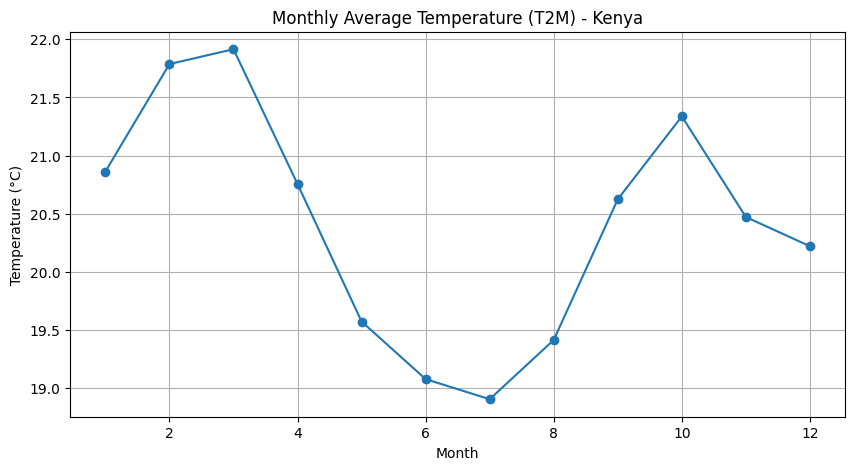

In [8]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Kenya")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Average Temperature Trend (T2M)

The line plot shows the variation of average monthly temperature (T2M) across the year in Kenya.

---

### Observations

- Temperatures are relatively **stable throughout the year**, ranging approximately between **19°C and 22°C**.
- The **highest temperatures** occur in:
  - **February and March**, peaking at around 21.8–22°C
- The **lowest temperatures** are observed in:
  - **June and July**, dropping to around 19°C

---

### Seasonal Pattern

- There is a **clear seasonal trend**:
  - **Warmer period:** January to March
  - **Cooler period:** June to August
  - Temperatures begin to rise again from **September onwards**

---

### Interpretation

- The pattern suggests a **mild seasonal climate**, without extreme temperature fluctuations.
- Mid-year cooling may be associated with **rainy seasons or increased cloud cover**.
- Overall, Kenya exhibits a **moderate and consistent temperature profile** year-round.

---

### Key Insight

The temperature variation is gradual and predictable, making it suitable for analyzing seasonal climate behavior and its relationship with other variables such as precipitation and humidity.

In [9]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(3), np.int32(7))

### Warmest and Coolest Months

Using the monthly average temperature data:

- The **warmest month** is **March (Month 3)**
- The **coolest month** is **July (Month 7)**

---

### Interpretation

- **March** represents the peak of the warm season, aligning with the earlier observed temperature rise from January to March.
- **July** falls within the coolest period of the year, consistent with the mid-year temperature dip.

---

### Key Insight

This confirms a clear seasonal cycle:
- Temperatures **increase early in the year**, peak around March  
- Then **decline towards mid-year**, reaching the lowest point in July  
- Followed by a gradual increase again towards the end of the year

These patterns are important for understanding climate seasonality and can be linked to rainfall and atmospheric changes.

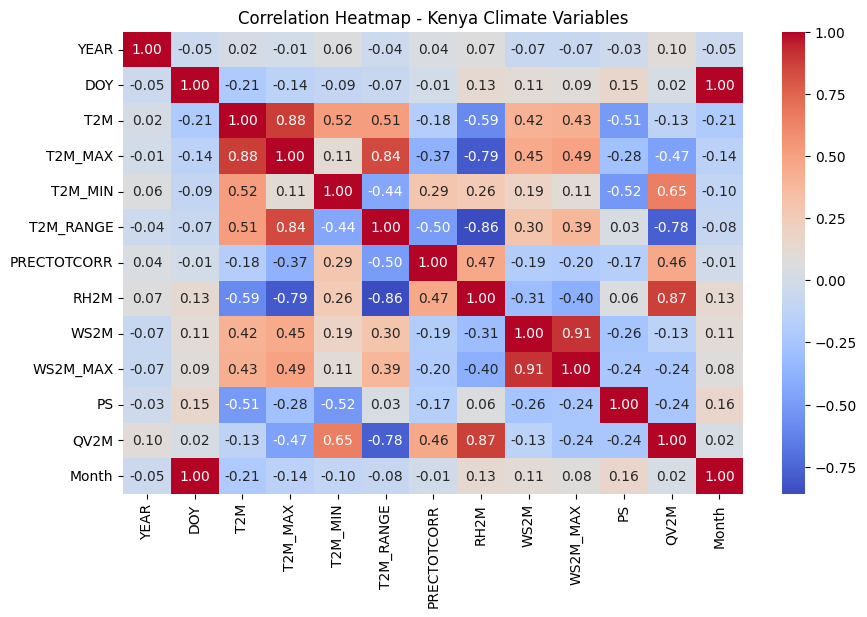

In [10]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Kenya Climate Variables")
plt.show()

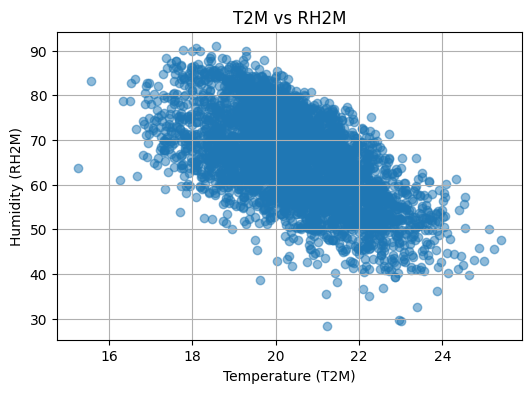

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

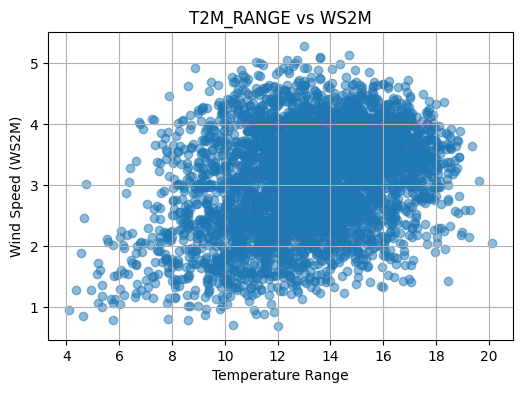

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [13]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.911136
dtype: float64

### Strongest Correlations

The top three strongest (non-self) correlations identified are:

- **DOY and Month:** 0.9966  
- **Month and DOY:** 0.9966  
- **WS2M_MAX and WS2M:** 0.9115  

---

### Interpretation

- **DOY vs Month (0.9966):**  
  This is an expected result since both variables represent time:
  - `DOY` (Day of Year) and `Month` are directly related  
  - The near-perfect correlation indicates **strong redundancy**, meaning one of them could be removed in modeling to avoid multicollinearity

- **WS2M_MAX vs WS2M (0.9115):**  
  This shows a strong positive relationship between:
  - Average wind speed (`WS2M`)
  - Maximum wind speed (`WS2M_MAX`)  

  As expected, days with higher average wind speeds tend to also have higher maximum wind speeds.

---

### Key Insight

- Time-based features (`DOY`, `Month`) are highly correlated and may not both be necessary for analysis.
- Wind-related variables are strongly linked, confirming internal consistency in the dataset.
- No unexpected strong correlations appear, suggesting variables are largely independent aside from logical relationships.

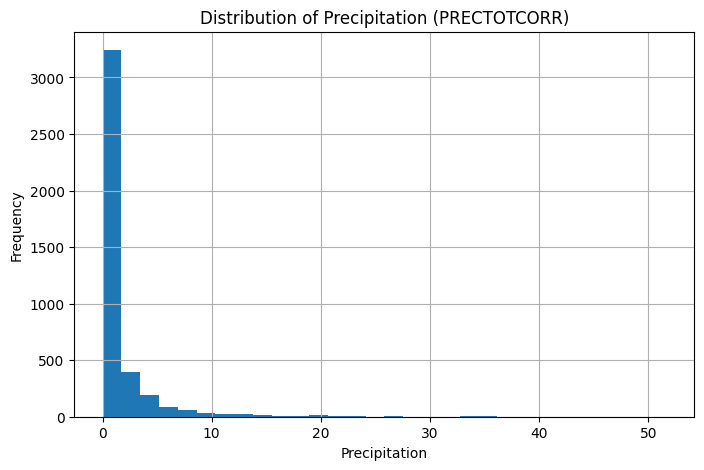

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

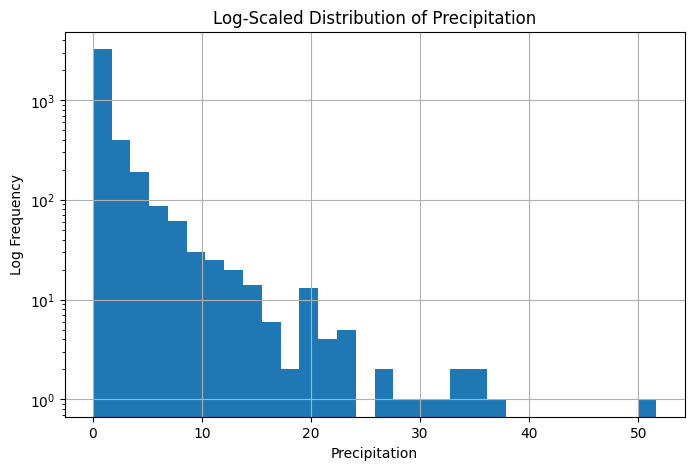

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.show()

### Distribution of Precipitation (Log Scale)

The histogram shows the distribution of precipitation (`PRECTOTCORR`) using a logarithmic scale on the frequency axis to better visualize skewed data.

---

### Observations

- The distribution is **heavily right-skewed**:
  - A large number of observations are concentrated near **0 mm (little to no rainfall)**
  - Frequencies drop sharply as precipitation values increase
- A few **extreme values** are present, reaching above **50 mm**

---

### Why Log Scale?

- The log scale helps reveal patterns that would otherwise be hidden due to:
  - A high concentration of low values
  - Very few high-value outliers
- It makes the **long tail** of the distribution more visible

---

### Interpretation

- Most days experience **dry or very light rainfall**
- Occasional days with **heavy precipitation** create a long tail
- This confirms that rainfall is **infrequent but intense when it occurs**

---

### Key Insight

The precipitation pattern is typical of climates with **distinct wet and dry periods**, where rainfall events are unevenly distributed and dominated by rare but significant storms.

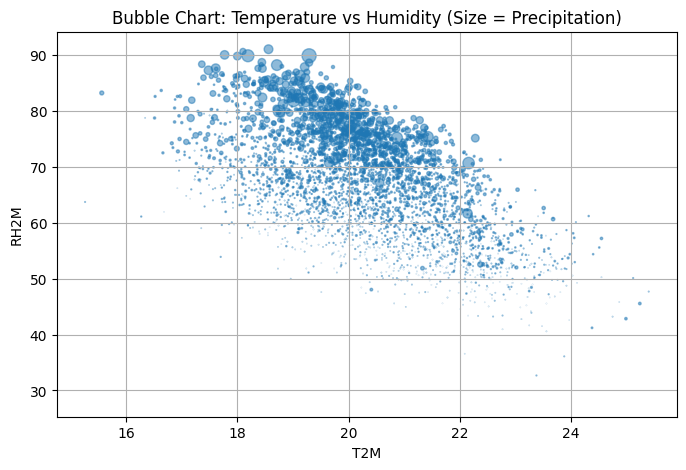

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Bubble Chart: Temperature vs Humidity (Size = Precipitation)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.grid(True)
plt.show()